# Customer Churn Prediction

### Objective
    The objective of this project is to predict whether the customer will churn (leave a service) based on their demographic and service usage data

### Goals
    - Perform data cleaning and preprocessing
    - Conduct Exploratory Data Analysis (EDA)
    - Build machine learning model to predict churn trend
    - Identify factors affecting customer churn

### Import neccessary library

Import the neccesary libraries for data manipulation, visualization and machine learning

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

### Load dataset

Load the dataset and inspect the dataset including: 
- Few rows of datase
- Data types

In this steps it help to understand the structure and quality of the data before processing

In [26]:
df = pd.read_csv('Telco_Customer_Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [27]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Data Cleaning

To make sure that all of the data in the dataset can be use (no missing values or inconsistent), performing the data cleaning is neccesary. Based on the dataset there are few things that need to be done including:

- Convert incorrect data types
- Handle missing values
- Remove irrelevent columns

This steps ensures that the dataset is clean and can be use for analysis and modeling

In [28]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

In [29]:
df.drop('customerID', axis=1, inplace=True)

### Exploratory Data analysis (EDA)

In this steps, it helps to understand the patterns, trends, and relationship in he data. The goals is to extract meaningful insights that can guide feature selection and model building. In this steps, it includes:
- Analyze the distribution og churn
- Visualize the relationship between features and churn
- Identify potential correlations

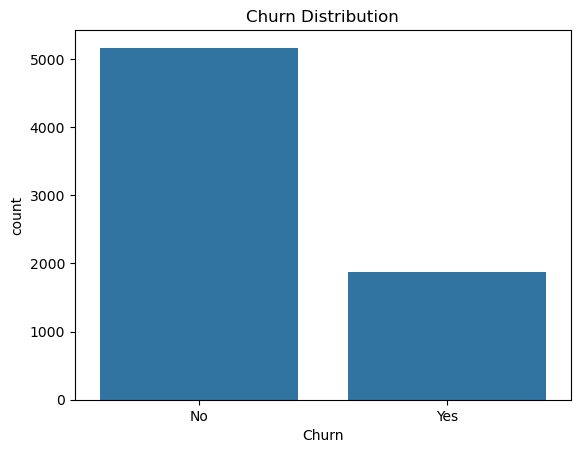

In [30]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

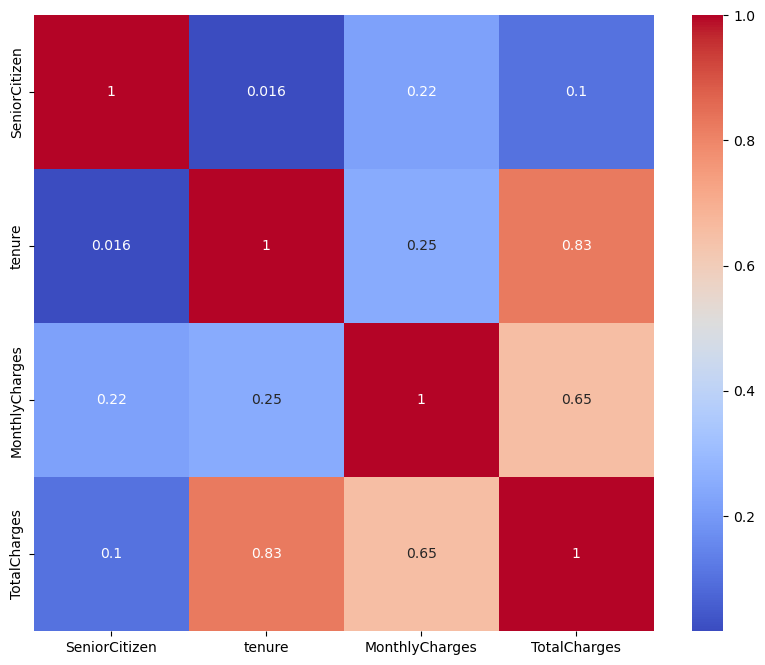

In [31]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

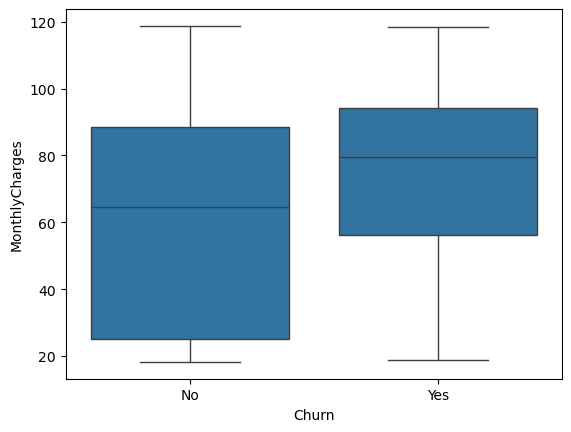

In [32]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

### Feature Engineering

Since we are going to train the machine learning models, it require a numerical input rather than categorical input. In this steps we convert categorical variables into dummy/indicator variables (one-hot encoding)

In [33]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [34]:
df = pd.get_dummies(df, drop_first=True)

### Split Data

To evaluate the dataset, we split the dataset into:
- Training set -> Used tto train the model
- Testing set -> Used to evaluate performance

In [35]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Feature Scaling

Use the StandardScaler to normalize features to have mean = 0 and standard deviation = 1

In [36]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Model Training

Use Logistic regression model for binary classification.

- A simple model that provides insighst into feature importance that works well for binary classification problems

In [37]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

### Prediction and Evaluation

To help access the model performace, we evaluate the model using:
- Accuracy -> Overall correctness
- Precision -> Correct positive predicions
- Recall -> Ability to detect churn
- F1-score -> Balance between accuracy and precision
- Confusion Matrix -> Prediciton breakdown

In [41]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



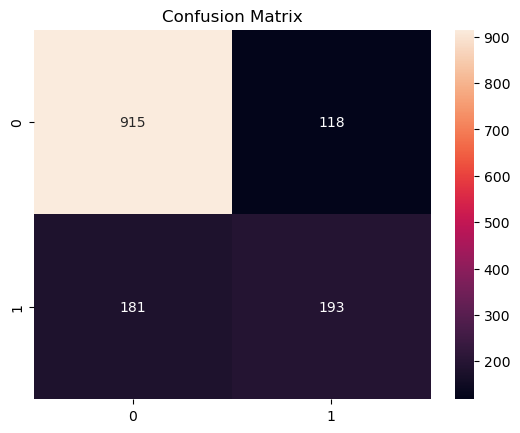

In [39]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

### Feature Importance

To understand the features that influence churn for future business decisions. Analyze the  model coefficient to identify the key drives of churn and features wih strongest impact.

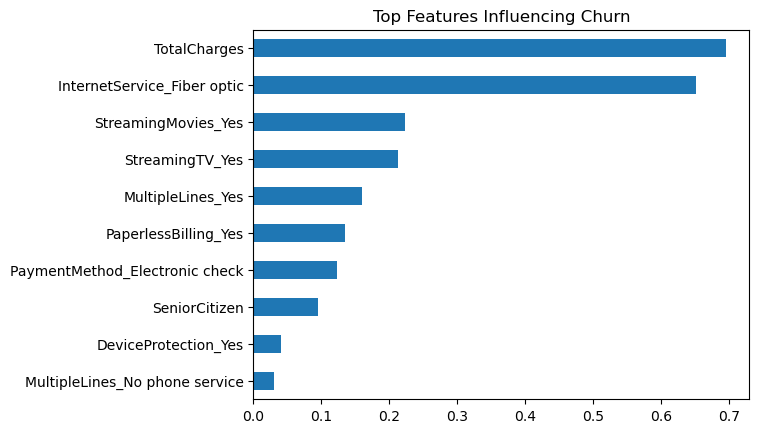

In [40]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().tail(10).plot(kind='barh')
plt.title('Top Features Influencing Churn')
plt.show()

#### Result

- **Accuracy:** 79%
- **Precision (Churn = 1):** 62%
- **Recall (Churn = 1):** 52%
- **F1-score (Churn = 1):** 56%

Based on the above evaluation, the model performance on churn prediction (Class 1) shows: 
- Lower recall (52%) which indicates that some churn cases are missed.
- Precision (62%) shows a relatively okay correctness when predicting churn